Part 2: ML Modeling

In [2]:
import pandas as pd

df = pd.read_csv('/content/sample_data/fraud_analysis.csv', header=0)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
features = [
    'step',
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'large_amount_flag',
    'high_risk_type',
    'account_drained',
    'risk_score'
]

target = 'isFraud'

In [4]:
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

In [5]:
print(df.head())

   step    amount     nameOrig  oldbalanceOrg  newbalanceOrig     nameDest  \
0     1   9839.64  C1231006815       170136.0       160296.36  M1979787155   
1     1   1864.28  C1666544295        21249.0        19384.72  M2044282225   
2     1    181.00  C1305486145          181.0            0.00   C553264065   
3     1    181.00   C840083671          181.0            0.00    C38997010   
4     1  11668.14  C2048537720        41554.0        29885.86  M1230701703   

   oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  type_CASH_OUT  \
0             0.0             0.0        0               0              0   
1             0.0             0.0        0               0              0   
2             0.0             0.0        1               0              0   
3         21182.0             0.0        1               0              1   
4             0.0             0.0        0               0              0   

   type_DEBIT  type_PAYMENT  type_TRANSFER  
0           0          

In [6]:
df['isFraud'].isna().sum()

np.int64(0)

In [7]:
df[df['isFraud'].isna()]

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER


In [8]:
df = df.dropna(subset=['isFraud'])

X = input features (Variables the model uses to learn fraud patterns)

y = target variable (This is what the model tries to predict)

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [11]:
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [33]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [26]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

In [34]:
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

In [35]:
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)
print("PR-AUC:", pr_auc_lr)

Precision: 0.029888141411351574
Recall: 0.9220937309799148
F1 Score: 0.057899564320110064
PR-AUC: 0.5716831606898914


In [36]:
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

In [37]:
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("PR-AUC:", pr_auc_rf)

Precision: 0.08106222908674207
Recall: 0.9902617163724894
F1 Score: 0.14985723496361794
PR-AUC: 0.9005289023448306


In [20]:
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

In [30]:
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)
print("PR-AUC:", pr_auc_xgb)

Precision: [0.00129113 0.00129114 0.00129114 ... 0.97222222 0.         1.        ]
Recall: [1.         1.         1.         ... 0.04260499 0.         0.        ]
F1 Score: 0.63469068128426
PR-AUC: 0.9599011226884413


In [28]:
from sklearn.metrics import precision_recall_curve, auc
precision_xgb, recall_xgb, thresholds = precision_recall_curve(y_test, y_prob_xgb)
pr_auc = auc(recall_xgb, precision_xgb)

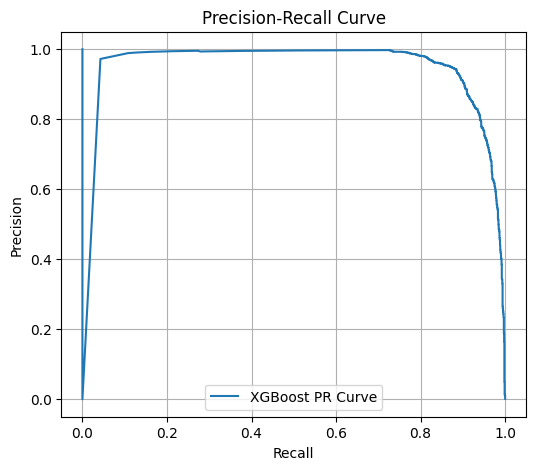

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(recall_xgb, precision_xgb, label="XGBoost PR Curve")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [38]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision': [precision_lr, precision_rf, precision_xgb],
    'Recall': [recall_lr, recall_rf, recall_xgb],
    'F1 Score': [f1_lr, f1_rf, f1_xgb],
    'PR-AUC': [pr_auc_lr, pr_auc_rf, pr_auc_xgb]
})

results

,Model,Precision,Recall,F1 Score,PR-AUC
0,Logistic Regression,0.029888,0.922094,0.057900,0.571683
1,Random Forest,0.081062,0.990262,0.149857,0.900529
2,XGBoost,"[0.0012911347840983745, 0.0012911357987242667,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.634691,0.959901


In [39]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[1221707   49174]
 [    128    1515]]


In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[1252437   18444]
 [     16    1627]]


In [41]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[1269037    1844]
 [     22    1621]]


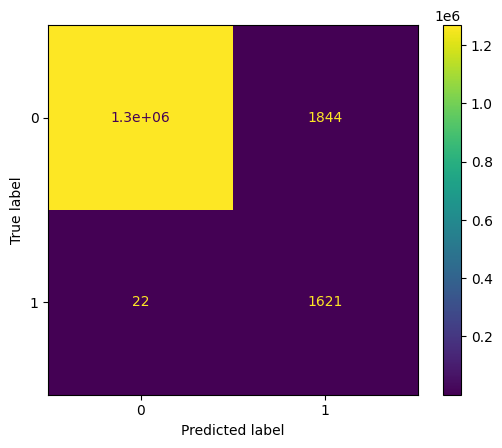

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)